In [1]:
import time
from dataclasses import dataclass

import numpy as np
from scipy import signal

import dearpygui.dearpygui as dpg
import matplotlib.pyplot as plt

In [ ]:
time.perf_counter_ns()

522719.417169


$$x(t)=\sigma(t)\,\eta_{\mathrm{bp}}(t)$$
where $\sigma(t)$ is slow-changing muscle activation envelope(muscle activation strength), $\eta_{\mathrm{bp}}(t)$ is zero-mean, unit-variance, bandpass stochastic process(Rapidly changing bandpass random carrier). 

$$x(t)=\sum_{i=1}^{M}\sum_k A_i\,p_i(t-t_{ik})$$
$$S_x(f)=\sum_{i=1}^{M}A_i^2\lambda_i |P_i(f)|^2$$
$$S_x(t,f)\approx \sigma^2(t)S_0(f)$$
$$x(t)=\sigma(t)\eta_{\mathrm{bp}}(t)$$

In [50]:
@dataclass
class EMGConfig:
    # 采样设置
    fs: float = 2000.0          # Hz，sEMG 常用 >= 1000 Hz
    duration: float = 6.0       # seconds

    # 带通滤波器设置
    lowcut: float = 20.0        # Hz，高通，去除 DC 和运动伪迹
    highcut: float = 450.0      # Hz，低通，保留主要 sEMG 频带
    filter_order: int = 4

    # 激活动力学
    tau_on: float = 0.04        # seconds，激活上升时间常数
    tau_off: float = 0.08       # seconds，激活下降时间常数

    # RMS 映射
    rms_rest: float = 0.02      # 静息 RMS，任意单位，例如 mV
    rms_max: float = 1.00       # 最大激活 RMS，任意单位，例如 mV
    gamma: float = 1.2          # 激活-幅值非线性指数

    # 伪迹 / 噪声
    sensor_noise_rms: float = 0.005   # 宽带测量噪声 RMS
    powerline_amp: float = 0.00       # 工频干扰幅值；设 0 表示不加
    powerline_freq: float = 50.0      # Hz，中国/欧洲常用 50，美国常用 60

    # 随机种子
    seed: int = 42

In [57]:
def make_trapezoid_command(t, bursts):
    """
    Generate several trapezoidal muscle activation commands u(t)。

    Parameters
    ----
    t : ndarray
        Time axis, in seconds.
    bursts : list of tuples
        Each burst has the format:
        (start, rise, hold, fall, level)

        start : start time of the burst
        rise  : rise time
        hold  : hold time
        fall  : fall time
        level : peak activation level,建议 0~1

    Returns
    ----
    u : ndarray
        Activation command, range approximately 0~1.
    """
    u = np.zeros_like(t, dtype=float)

    for start, rise, hold, fall, level in bursts:
        t0 = start
        t1 = t0 + rise
        t2 = t1 + hold
        t3 = t2 + fall

        # rasing stage
        idx = (t >= t0) & (t < t1)
        if rise > 0:
            u[idx] = np.maximum(u[idx], level * (t[idx] - t0) / rise)

        # plateau stage
        idx = (t >= t1) & (t < t2)
        u[idx] = np.maximum(u[idx], level)

        # falling stage
        idx = (t >= t2) & (t < t3)
        if fall > 0:
            u[idx] = np.maximum(u[idx], level * (1.0 - (t[idx] - t2) / fall))

    return np.clip(u, 0.0, 1.0)

def first_order_activation_dynamics(u, fs, tau_on=0.04, tau_off=0.08):
    """
    Transform the idealized neural command u[n] into a smoother muscle activation a[n].

    The continuous-time form can be written as:
        da/dt = (u - a) / tau

    Discretized:
        a[n] = alpha * a[n-1] + (1-alpha) * u[n]

    When u[n] > a[n-1], use tau_on;
    When u[n] <= a[n-1], use tau_off.

    This simulates the phenomenon that muscle activation rises and falls at different speeds.
    """
    u = np.asarray(u, dtype=float)
    a = np.zeros_like(u)
    dt = 1.0 / fs

    for n in range(1, len(u)):
        tau = tau_on if u[n] > a[n - 1] else tau_off
        alpha = np.exp(-dt / tau)
        a[n] = alpha * a[n - 1] + (1.0 - alpha) * u[n]

    return np.clip(a, 0.0, 1.0)

def generate_bandpass_carrier(n, fs, lowcut, highcut, order=4, rng=None):
    """
    Generate a bandpass Gaussian random process eta[n] with zero mean and unit RMS.

    Steps:
        1. Generate white Gaussian noise w[n]
        2. Pass through a Butterworth bandpass filter
        3. Remove mean
        4. Normalize RMS

    Note:
        The eta[n] here is the "random carrier" of EMG, not the measurement noise contamination.
    """
    if rng is None:
        rng = np.random.default_rng()

    nyq = fs / 2.0
    if not (0 < lowcut < highcut < nyq):
        raise ValueError(
            f"need 0 < lowcut < highcut < fs/2,"
            f"current lowcut={lowcut}, highcut={highcut}, fs/2={nyq}"
        )

    # Gaussian white noise
    w = rng.standard_normal(n)

    # Butterworth bandpass filter, using SOS form to improve numerical stability
    sos = signal.butter(
        N=order,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos"
    )

    # Zero-phase filtering, to avoid phase delay; convenient for offline simulation
    eta = signal.sosfiltfilt(sos, w)

    # Remove mean
    eta = eta - np.mean(eta)

    # RMS Normalization
    rms = np.sqrt(np.mean(eta ** 2))
    eta = eta / (rms + 1e-12)

    return eta


Generator(PCG64) at 0x23E538DF220

In [ ]:
config = EMGConfig(
        fs=2000.0,
        duration=6.0,
        lowcut=20.0,
        highcut=450.0,
        rms_rest=0.02,
        rms_max=1.00,
        gamma=1.2,
        sensor_noise_rms=0.005,
        powerline_amp=0.00,
        seed=7
    )

rng = np.random.default_rng(42)

fs = 1000
tau_on = 0.04
tau_off = 0.08
n = int(round(10 * fs))
t = np.arange(n) / fs

# 示例：两个肌肉激活 burst
bursts = [
    # start, rise, hold, fall, level
    (0.6, 0.25, 1.20, 0.35, 0.65),
    (3.0, 0.15, 1.10, 0.25, 1.00),
]

# 神经命令 u[n]
u = make_trapezoid_command(t, bursts)

# 肌肉激活 a[n]
a = first_order_activation_dynamics(
        u,
        fs=fs,
        tau_on=tau_on,
        tau_off=tau_off
    )

sigma_target = config.rms_rest + (
    config.rms_max - config.rms_rest
) * (a ** config.gamma)

# 生成单位 RMS 带通随机载波
eta = generate_bandpass_carrier(
    n=n,
    fs=fs,
    lowcut=config.lowcut,
    highcut=config.highcut,
    order=config.filter_order,
    rng=rng
)

# 根据模型生成 clean EMG
# if model == "gaussian_am":
sigma_eff = sigma_target
x_clean = sigma_eff * eta

# 加入宽带传感器噪声
sensor_noise = config.sensor_noise_rms * rng.standard_normal(n)

# 可选：加入工频干扰
if config.powerline_amp > 0:
    phase = rng.uniform(0, 2 * np.pi)
    powerline = config.powerline_amp * np.sin(
        2 * np.pi * config.powerline_freq * t + phase
    )
else:
    powerline = np.zeros(n)

x = x_clean + sensor_noise + powerline


In [1]:
def simulate_emg(config, model="gaussian_am"):
    """
    simulate EMG.

    parameters
    ----
    config : EMGConfig
        configuration parameters.
    model : str
        "gaussian_am"    : Gaussian bandpass carrier + activation envelope modulation
        "scale_mixture"  : Scale mixture model with random variances

    returns
    ----
    result : dict
        Contains time, commands, activations, target RMS, carrier, and synthesized EMG.
    """
    rng = np.random.default_rng(config.seed)

    fs = config.fs
    n = int(round(config.duration * fs))
    t = np.arange(n) / fs

    bursts = [
        # start, rise, hold, fall, level
        (0.6, 0.25, 1.20, 0.35, 0.65),
        (3.0, 0.15, 1.10, 0.25, 1.00),
    ]

    # neural command u[n]
    u = make_trapezoid_command(t, bursts)

    # muscle activation a[n]
    a = first_order_activation_dynamics(
        u,
        fs=fs,
        tau_on=config.tau_on,
        tau_off=config.tau_off
    )

    # activation -> target RMS
    sigma_target = config.rms_rest + (
        config.rms_max - config.rms_rest
    ) * (a ** config.gamma)

    # generate unit RMS bandpass random carrier
    eta = generate_bandpass_carrier(
        n=n,
        fs=fs,
        lowcut=config.lowcut,
        highcut=config.highcut,
        order=config.filter_order,
        rng=rng
    )

    # generate clean EMG based on the specified model
    if model == "gaussian_am":
        sigma_eff = sigma_target
        x_clean = sigma_eff * eta

    elif model == "scale_mixture":
        # alpha 越小，尾部越重；例如 4~10 比较常用
        sigma_eff = draw_scale_mixture_sigma(
            sigma_target=sigma_target,
            fs=fs,
            alpha=5.0,
            block_ms=25.0,
            rng=rng
        )
        x_clean = sigma_eff * eta

    else:
        raise ValueError("model must be 'gaussian_am' or 'scale_mixture'")

    # generate sensor noise
    sensor_noise = config.sensor_noise_rms * rng.standard_normal(n)

    # optionally add powerline interference
    if config.powerline_amp > 0:
        phase = rng.uniform(0, 2 * np.pi)
        powerline = config.powerline_amp * np.sin(
            2 * np.pi * config.powerline_freq * t + phase
        )
    else:
        powerline = np.zeros(n)

    x = x_clean + sensor_noise + powerline

    return {
        "t": t,
        "u": u,
        "activation": a,
        "sigma_target": sigma_target,
        "sigma_eff": sigma_eff,
        "carrier": eta,
        "emg_clean": x_clean,
        "emg": x,
        "fs": fs,
        "model": model,
    }

Text(0.5, 1.0, 'Trapezoidal Muscle Activation Command')

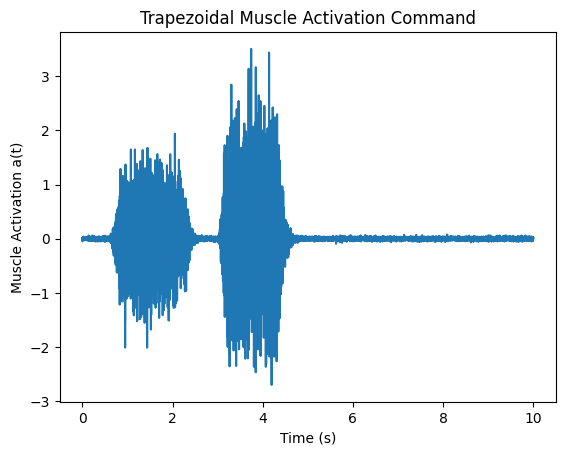

In [74]:
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Muscle Activation a(t)')
plt.title('Trapezoidal Muscle Activation Command')

Text(0.5, 1.0, 'Trapezoidal Muscle Activation Command')

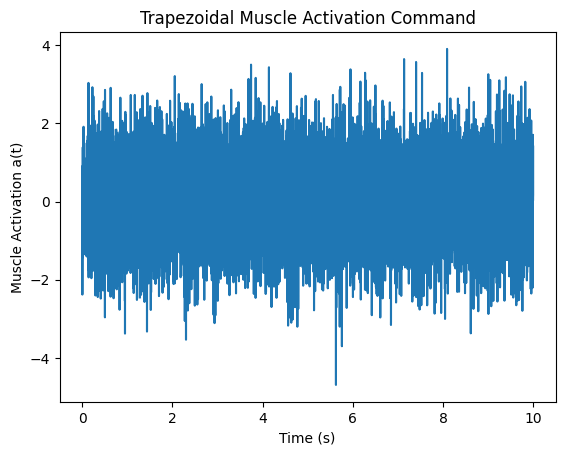

In [61]:
rng = np.random.default_rng()
w = rng.standard_normal(n)
w.shape



plt.plot(t, eta)
plt.xlabel('Time (s)')
plt.ylabel('Muscle Activation a(t)')
plt.title('Trapezoidal Muscle Activation Command')

Text(0.5, 1.0, 'Trapezoidal Muscle Activation Command')

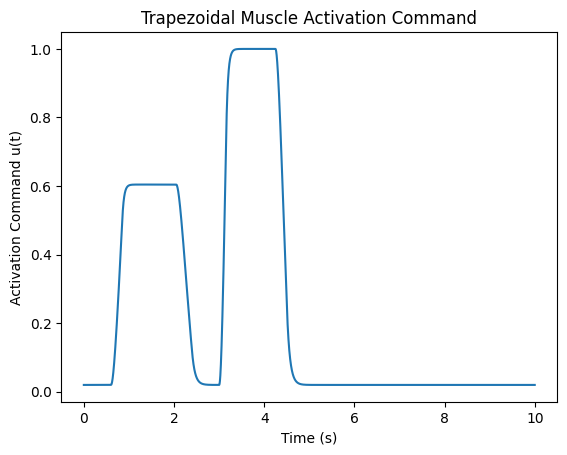

In [81]:
# print(np.where(u != 0)[0].shape)
plt.plot(t, sigma_target)
plt.xlabel('Time (s)')
plt.ylabel('Activation Command u(t)')
plt.title('Trapezoidal Muscle Activation Command')

Text(0.5, 0, 'Frequency (Hz)')

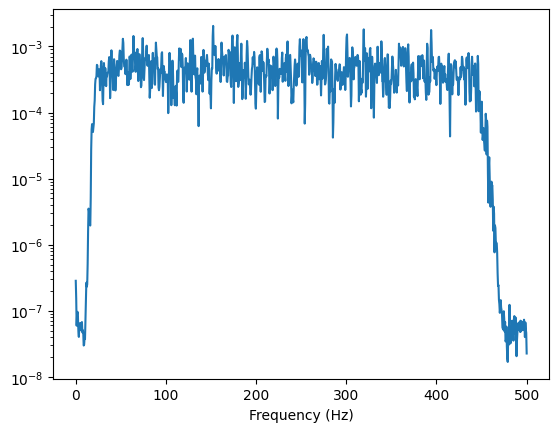

In [72]:
f, Pxx = signal.welch(x, fs=fs, nperseg=2048)
plt.semilogy(f, Pxx)
plt.xlabel('Frequency (Hz)')